# 02 — Exploratory Data Analysis

Visualize kidney stone admission trends across time, geography, demographics, and seasonality.
All plots are saved to `outputs/plots/` with a `02_` prefix.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", palette="deep", font_scale=1.1)

OUTPUT_DIR = Path("../outputs")
PLOT_DIR = OUTPUT_DIR / "plots"
METRICS_DIR = OUTPUT_DIR / "metrics"
PLOT_DIR.mkdir(parents=True, exist_ok=True)
METRICS_DIR.mkdir(parents=True, exist_ok=True)

kidney = pd.read_parquet(OUTPUT_DIR / "kidney_sih.parquet")
print(f"Loaded {len(kidney):,} kidney stone admissions")

Loaded 206,500 kidney stone admissions


## Yearly Trend

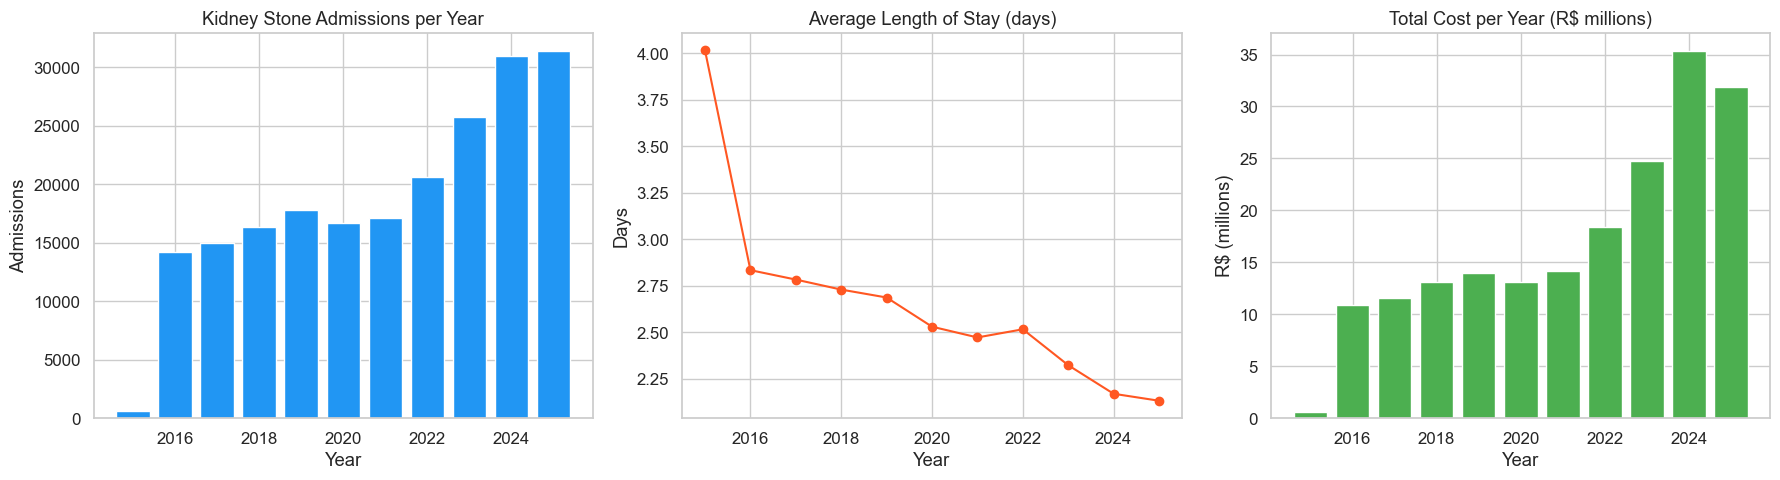

In [2]:
yearly = kidney.groupby("year").agg(
    admissions=("DIAG_PRINC", "count"),
    avg_stay=("DIAS_PERM", "mean"),
    avg_cost=("VAL_TOT", "mean"),
    total_cost=("VAL_TOT", "sum"),
).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].bar(yearly["year"], yearly["admissions"], color="#2196F3")
axes[0].set_title("Kidney Stone Admissions per Year")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Admissions")

axes[1].plot(yearly["year"], yearly["avg_stay"], "o-", color="#FF5722")
axes[1].set_title("Average Length of Stay (days)")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Days")

axes[2].bar(yearly["year"], yearly["total_cost"] / 1e6, color="#4CAF50")
axes[2].set_title("Total Cost per Year (R$ millions)")
axes[2].set_xlabel("Year")
axes[2].set_ylabel("R$ (millions)")

plt.tight_layout()
plt.savefig(PLOT_DIR / "02_yearly_trend.png", dpi=150, bbox_inches="tight")
plt.show()

## Seasonality

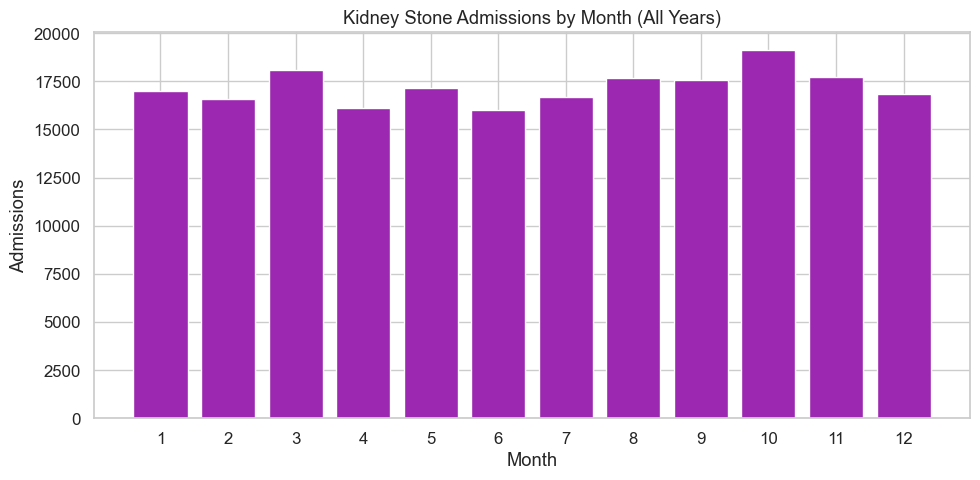

In [3]:
monthly = kidney.groupby("month")["DIAG_PRINC"].count()

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(monthly.index, monthly.values, color="#9C27B0")
ax.set_title("Kidney Stone Admissions by Month (All Years)")
ax.set_xlabel("Month")
ax.set_ylabel("Admissions")
ax.set_xticks(range(1, 13))

plt.tight_layout()
plt.savefig(PLOT_DIR / "02_seasonality.png", dpi=150, bbox_inches="tight")
plt.show()

## Demographics: Age and Sex

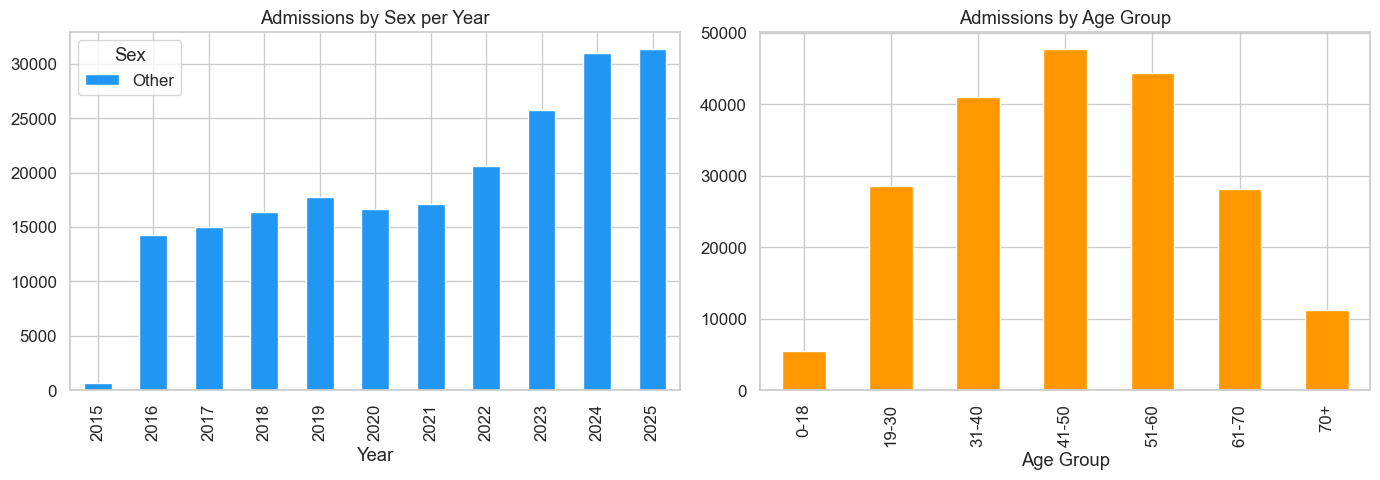

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sex distribution over time
sex_map = {1: "Male", 3: "Female"}
kidney["sex_label"] = kidney["SEXO"].map(sex_map).fillna("Other")
sex_yearly = kidney.groupby(["year", "sex_label"]).size().unstack(fill_value=0)
sex_yearly.plot(kind="bar", stacked=True, ax=axes[0], color=["#2196F3", "#E91E63", "#9E9E9E"])
axes[0].set_title("Admissions by Sex per Year")
axes[0].set_xlabel("Year")
axes[0].legend(title="Sex")

# Age distribution
kidney["age_group"] = pd.cut(
    kidney["IDADE"], bins=[0, 18, 30, 40, 50, 60, 70, 120],
    labels=["0-18", "19-30", "31-40", "41-50", "51-60", "61-70", "70+"]
)
age_counts = kidney["age_group"].value_counts().sort_index()
age_counts.plot(kind="bar", ax=axes[1], color="#FF9800")
axes[1].set_title("Admissions by Age Group")
axes[1].set_xlabel("Age Group")

plt.tight_layout()
plt.savefig(PLOT_DIR / "02_demographics.png", dpi=150, bbox_inches="tight")
plt.show()

## Geographic Hotspots

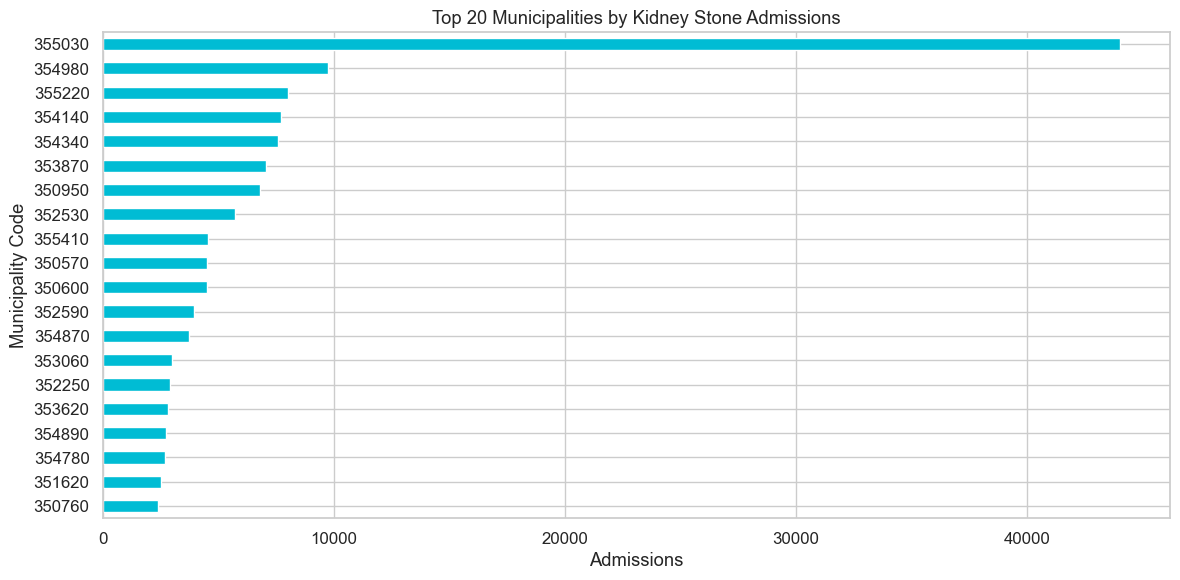

In [5]:
# Top 20 municipalities by admission count
top_munic = kidney.groupby("MUNIC_MOV").size().nlargest(20)

fig, ax = plt.subplots(figsize=(12, 6))
top_munic.plot(kind="barh", ax=ax, color="#00BCD4")
ax.set_title("Top 20 Municipalities by Kidney Stone Admissions")
ax.set_xlabel("Admissions")
ax.set_ylabel("Municipality Code")
ax.invert_yaxis()

plt.tight_layout()
plt.savefig(PLOT_DIR / "02_geographic_hotspots.png", dpi=150, bbox_inches="tight")
plt.show()

## Sub-Diagnosis Breakdown

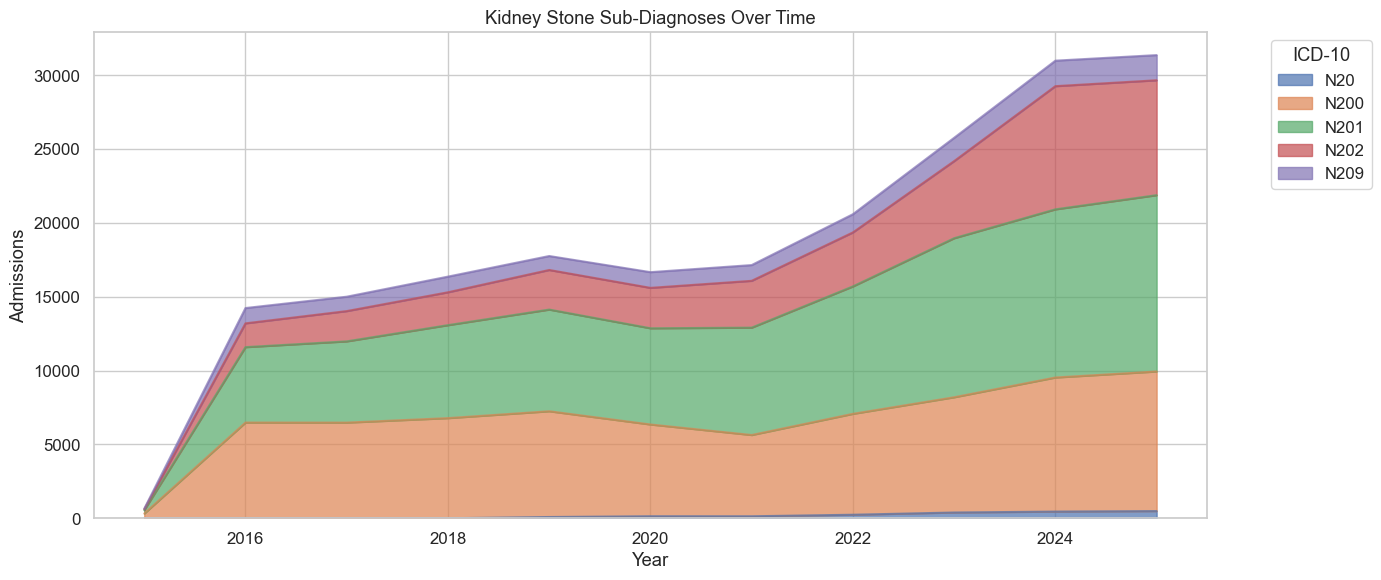

In [6]:
subdiag = kidney.groupby(["year", "DIAG_PRINC"]).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(14, 6))
subdiag.plot(kind="area", stacked=True, ax=ax, alpha=0.7)
ax.set_title("Kidney Stone Sub-Diagnoses Over Time")
ax.set_xlabel("Year")
ax.set_ylabel("Admissions")
ax.legend(title="ICD-10", bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.savefig(PLOT_DIR / "02_subdiagnosis.png", dpi=150, bbox_inches="tight")
plt.show()

## Save EDA Metrics

In [7]:
first_year = yearly.iloc[0]
last_year = yearly.iloc[-1]

eda_metrics = {
    "total_admissions": int(len(kidney)),
    "year_range": [int(kidney["year"].min()), int(kidney["year"].max())],
    "growth_pct": round((last_year["admissions"] / first_year["admissions"] - 1) * 100, 1),
    "avg_stay_first_year": round(float(first_year["avg_stay"]), 2),
    "avg_stay_last_year": round(float(last_year["avg_stay"]), 2),
    "pct_male": round((kidney["SEXO"] == 1).mean() * 100, 1),
    "pct_female": round((kidney["SEXO"] == 3).mean() * 100, 1),
    "top_5_municipalities": top_munic.head(5).to_dict(),
}

with open(METRICS_DIR / "eda_metrics.json", "w") as f:
    json.dump(eda_metrics, f, indent=2, default=str)

print("EDA complete. Saved metrics to outputs/metrics/eda_metrics.json")
print(f"Key finding: {eda_metrics['growth_pct']}% growth in kidney stone admissions")

EDA complete. Saved metrics to outputs/metrics/eda_metrics.json
Key finding: 4800.3% growth in kidney stone admissions
